In [1]:
# 18/12/2025 Running TF-COMBs to find what TFs co-occur with STAT3 on the top 300 differentially accessible peaks between WT and SteE KO Salmonella infected iBMDMs

# Using new tables Peter sent me for iBMDMs
#%pip install --upgrade pip
#%pip install git+https://github.com/loosolab/TF-COMB

# NB: need to comment out this line from turtle import end_fill from the utils.py file
# NB: also need to replace var_name=['TF2'] with var_name='TF2' in objects.py so market_basket works

# needed for os.path.join
import os

# use to show all outputs from a cell, not just the last one
from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = "all"

import pandas as pd

from tfcomb import CombObj, DiffCombObj

import tfcomb
print("tfcomb version: ", tfcomb.__version__)

tfcomb version:  1.1.1


In [2]:
# set up a CombObj
background = CombObj()

# search for motifs
dir_path = "/scratch/prj/id_hill_sims_wellcda/SteE_revisions/"
background.TFBS_from_motifs(regions = os.path.join(dir_path, "TF-COMBs/ATACSeq.OCRs.DESeq2.ssaV_vs_WT.all_regions.bed"),
                   motifs = os.path.join(dir_path, "TF-COMBs/HOCOMOCOv11_core_MOUSE_mono_meme_format.meme"),
                   genome = os.path.join(dir_path, "genome.fa"),
                   #motif_pvalue = 0.01, # less strict than default 0.00001
                   threads = 10)

# overwrite counts with larger window
background.count_within(max_dist=500,
                        #binarize = True, # if True then each cooccurence is only counted once per window
                        threads=10)

background.market_basket(threads=10)

INFO: Scanning for TFBS with 10 thread(s)...
INFO: Progress: 10%
INFO: Progress: 20%
INFO: Progress: 30%
INFO: Progress: 40%
INFO: Progress: 50%
INFO: Progress: 60%
INFO: Progress: 70%
INFO: Progress: 80%
INFO: Progress: 90%
INFO: Finished!
INFO: Processing scanned TFBS
INFO: Identified 1003908 TFBS (356 unique names) within given regions
INFO: Setting up binding sites for counting
INFO: Counting co-occurrences within sites
INFO: Counting co-occurrence within background
INFO: Progress: 10%
INFO: Progress: 20%
INFO: Progress: 30%
INFO: Progress: 40%
INFO: Progress: 50%
INFO: Progress: 60%
INFO: Progress: 70%
INFO: Progress: 80%
INFO: Progress: 90%
INFO: Finished!
INFO: Done finding co-occurrences! Run .market_basket() to estimate significant pairs
INFO: Market basket analysis is done! Results are found in <CombObj>.rules


In [3]:
background.rules

,TF1,TF2,TF1_TF2_count,TF1_count,TF2_count,cosine,zscore
ATF4_MOUSE.H11MO.0.A-CEBPG_MOUSE.H11MO.0.B,ATF4_MOUSE.H11MO.0.A,CEBPG_MOUSE.H11MO.0.B,6993,1112,1141,6.208237,1125.945121
CEBPG_MOUSE.H11MO.0.B-ATF4_MOUSE.H11MO.0.A,CEBPG_MOUSE.H11MO.0.B,ATF4_MOUSE.H11MO.0.A,6993,1141,1112,6.208237,1125.945121
ATF4_MOUSE.H11MO.0.A-DDIT3_MOUSE.H11MO.0.C,ATF4_MOUSE.H11MO.0.A,DDIT3_MOUSE.H11MO.0.C,5447,1112,1094,4.938514,889.239659
DDIT3_MOUSE.H11MO.0.C-ATF4_MOUSE.H11MO.0.A,DDIT3_MOUSE.H11MO.0.C,ATF4_MOUSE.H11MO.0.A,5447,1094,1112,4.938514,889.239659
CEBPG_MOUSE.H11MO.0.B-DDIT3_MOUSE.H11MO.0.C,CEBPG_MOUSE.H11MO.0.B,DDIT3_MOUSE.H11MO.0.C,5462,1141,1094,4.888777,791.866088
...,...,...,...,...,...,...,...
MAX_MOUSE.H11MO.0.A-HXB8_MOUSE.H11MO.0.C,MAX_MOUSE.H11MO.0.A,HXB8_MOUSE.H11MO.0.C,1,781,653,0.001400,-3.446028
HNF6_MOUSE.H11MO.0.A-MYC_MOUSE.H11MO.0.A,HNF6_MOUSE.H11MO.0.A,MYC_MOUSE.H11MO.0.A,1,593,891,0.001376,-4.574763
MYC_MOUSE.H11MO.0.A-HNF6_MOUSE.H11MO.0.A,MYC_MOUSE.H11MO.0.A,HNF6_MOUSE.H11MO.0.A,1,891,593,0.001376,-4.574763
ATF1_MOUSE.H11MO.0.B-HLF_MOUSE.H11MO.0.C,ATF1_MOUSE.H11MO.0.B,HLF_MOUSE.H11MO.0.C,1,831,745,0.001271,-3.793753


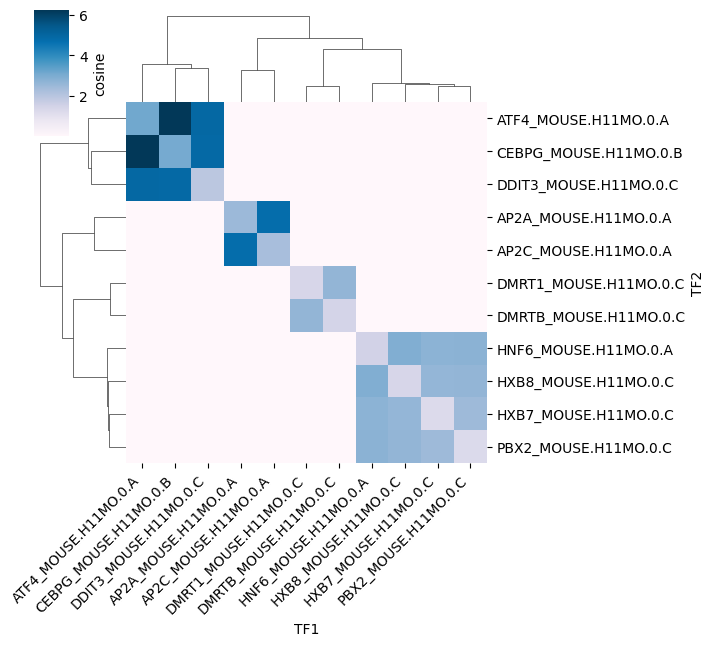

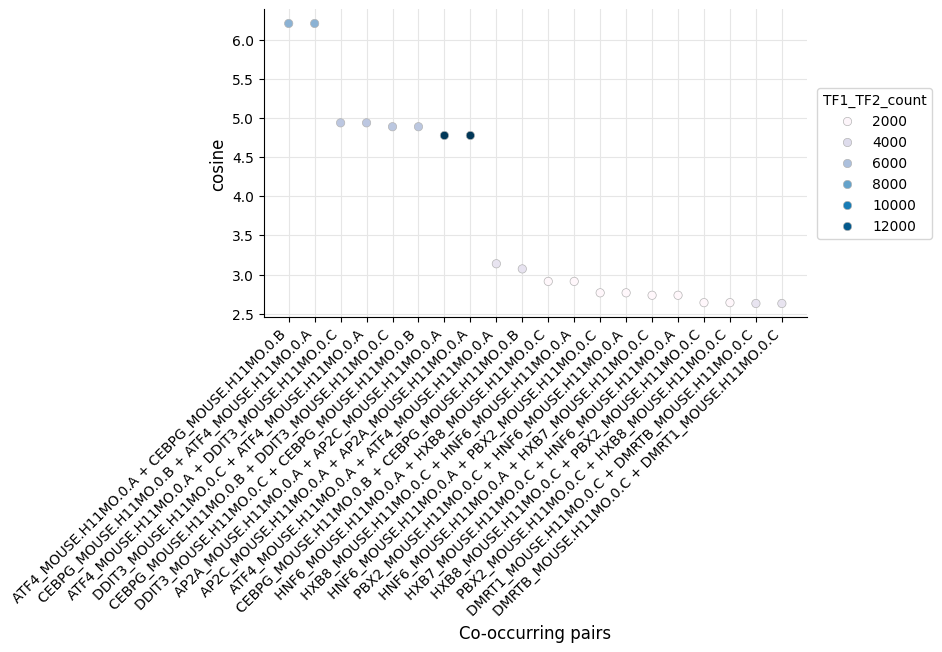

In [4]:
_ = background.plot_heatmap()
_ = background.plot_bubble()

In [5]:
# filter for STAT3 containing pairs
background.TFBS[0].__dict__

# look at all TFBS sites containing STAT3
# this way returns a list of TFBS object
stat3_tfbs = [x for x in background.TFBS if "STAT3" in x.name]
stat3_tfbs[:5]

len(stat3_tfbs)
## 1,773 stat3 sites

# get all STAT3 motif variants
stat3_variants = sorted(set(x.name for x in background.TFBS if "STAT3" in x.name))
print(stat3_variants)

# filter the significant co-occurrence pairs to those with STAT3 co-occurrence
sorted(set(x.name for x in background.TFBS if "STAT3" in x.name))

stat3_pairs = background.select_TF_rules(["STAT3_MOUSE.H11MO.0.A"])

stat3_pairs.rules.head()


{'chrom': 'chr1',
 'start': 4256793,
 'end': 4256837,
 'name': 'ZN322_MOUSE.H11MO.0.B',
 'score': 11.80539,
 'strand': '+',
 'get_width': <function tobias.utils.regions.OneRegion.get_width(self)>}

[chr1	6444852	6444864	STAT3_MOUSE.H11MO.0.A	10.57249	+,
 chr1	6624761	6624773	STAT3_MOUSE.H11MO.0.A	10.66145	-,
 chr1	6691520	6691532	STAT3_MOUSE.H11MO.0.A	9.33525	-,
 chr1	13206891	13206903	STAT3_MOUSE.H11MO.0.A	9.37977	+,
 chr1	13374400	13374412	STAT3_MOUSE.H11MO.0.A	9.65438	-]

1773

['STAT3_MOUSE.H11MO.0.A']


['STAT3_MOUSE.H11MO.0.A']

INFO: Selected 1 rules
INFO: Creating subset of object


,TF1,TF2,TF1_TF2_count,TF1_count,TF2_count,cosine,zscore
STAT3_MOUSE.H11MO.0.A-STAT3_MOUSE.H11MO.0.A,STAT3_MOUSE.H11MO.0.A,STAT3_MOUSE.H11MO.0.A,259,1773,1773,0.14608,28.039597


In [6]:
background.__dict__.keys()

dict_keys(['verbosity', 'logger', 'prefix', 'TFBS', 'TF_names', 'count_names', 'TF_counts', 'pair_counts', 'bg_counts_mean', 'bg_counts_std', 'rules', 'network', 'min_dist', 'max_dist', 'directional', 'min_overlap', 'max_overlap', 'anchor', 'anchor_to_int', 'distObj', 'n_TFBS', 'stranded', 'binarize', 'name_to_idx', '_sites', 'zscore', 'TF_table'])

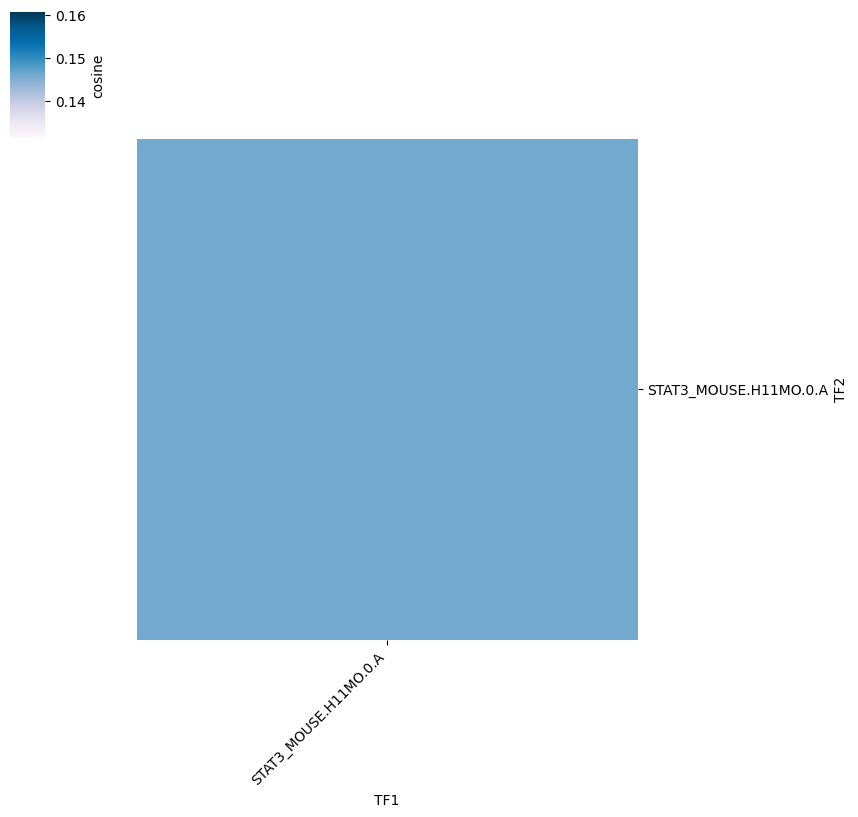

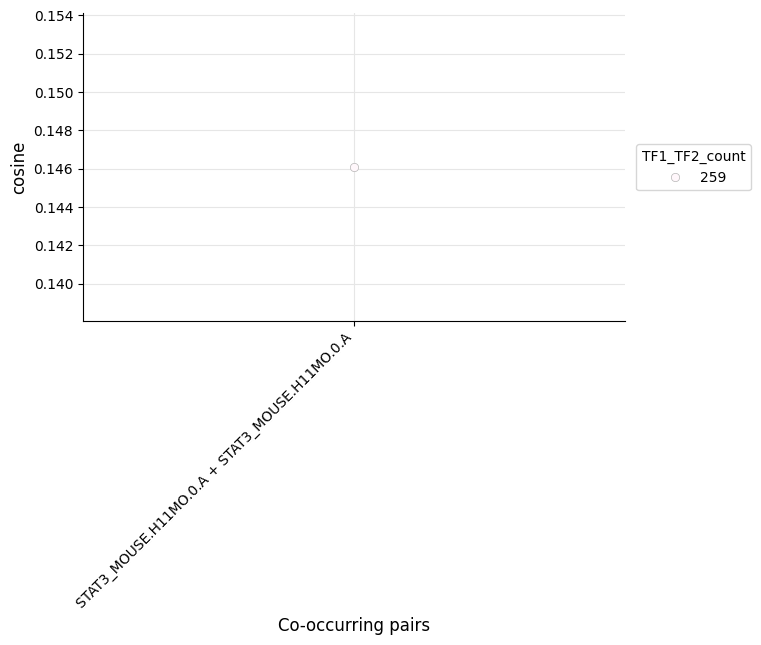

In [7]:
_ = stat3_pairs.plot_heatmap()
_ = stat3_pairs.plot_bubble()

INFO: Scanning for TFBS with 4 thread(s)...
INFO: Progress: 9%
INFO: Progress: 18%
INFO: Progress: 28%
INFO: Progress: 36%
INFO: Progress: 45%
INFO: Progress: 55%
INFO: Progress: 65%
INFO: Progress: 73%
INFO: Progress: 83%
INFO: Progress: 91%
INFO: Finished!
INFO: Processing scanned TFBS
INFO: Identified 49063 TFBS (356 unique names) within given regions
INFO: Setting up binding sites for counting
INFO: Counting co-occurrences within sites
INFO: Counting co-occurrence within background
INFO: Progress: 10%
INFO: Progress: 20%
INFO: Progress: 36%
INFO: Progress: 40%
INFO: Progress: 52%
INFO: Progress: 60%
INFO: Progress: 74%
INFO: Progress: 86%
INFO: Finished!
INFO: Done finding co-occurrences! Run .market_basket() to estimate significant pairs
INFO: Market basket analysis is done! Results are found in <CombObj>.rules


,TF1,TF2,TF1_TF2_count,TF1_count,TF2_count,cosine,zscore
NF2L2_MOUSE.H11MO.0.A-NFE2_MOUSE.H11MO.0.A,NF2L2_MOUSE.H11MO.0.A,NFE2_MOUSE.H11MO.0.A,2412,238,263,9.640753,449.150368
NFE2_MOUSE.H11MO.0.A-NF2L2_MOUSE.H11MO.0.A,NFE2_MOUSE.H11MO.0.A,NF2L2_MOUSE.H11MO.0.A,2412,263,238,9.640753,449.150368
BACH2_MOUSE.H11MO.0.A-NF2L2_MOUSE.H11MO.0.A,BACH2_MOUSE.H11MO.0.A,NF2L2_MOUSE.H11MO.0.A,2407,268,238,9.530599,382.932831
NF2L2_MOUSE.H11MO.0.A-BACH2_MOUSE.H11MO.0.A,NF2L2_MOUSE.H11MO.0.A,BACH2_MOUSE.H11MO.0.A,2407,238,268,9.530599,382.932831
BACH1_MOUSE.H11MO.0.C-NF2L2_MOUSE.H11MO.0.A,BACH1_MOUSE.H11MO.0.C,NF2L2_MOUSE.H11MO.0.A,1706,147,238,9.120778,378.156852
...,...,...,...,...,...,...,...
EHF_MOUSE.H11MO.0.B-HXA1_MOUSE.H11MO.0.C,EHF_MOUSE.H11MO.0.B,HXA1_MOUSE.H11MO.0.C,1,268,105,0.005961,-3.512323
HXA1_MOUSE.H11MO.0.C-BACH2_MOUSE.H11MO.0.A,HXA1_MOUSE.H11MO.0.C,BACH2_MOUSE.H11MO.0.A,1,105,268,0.005961,-3.851957
HXA1_MOUSE.H11MO.0.C-EHF_MOUSE.H11MO.0.B,HXA1_MOUSE.H11MO.0.C,EHF_MOUSE.H11MO.0.B,1,105,268,0.005961,-3.512323
ELF3_MOUSE.H11MO.0.B-HXA1_MOUSE.H11MO.0.C,ELF3_MOUSE.H11MO.0.B,HXA1_MOUSE.H11MO.0.C,1,311,105,0.005534,-3.673924


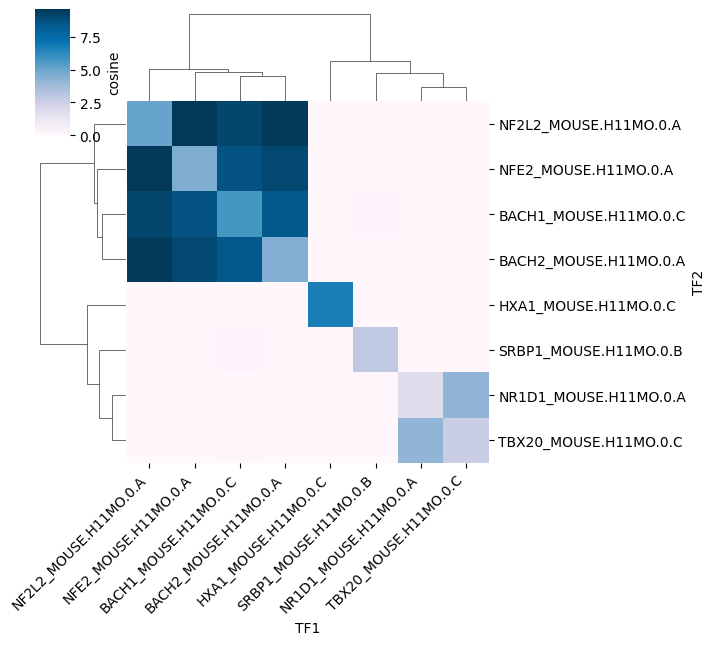

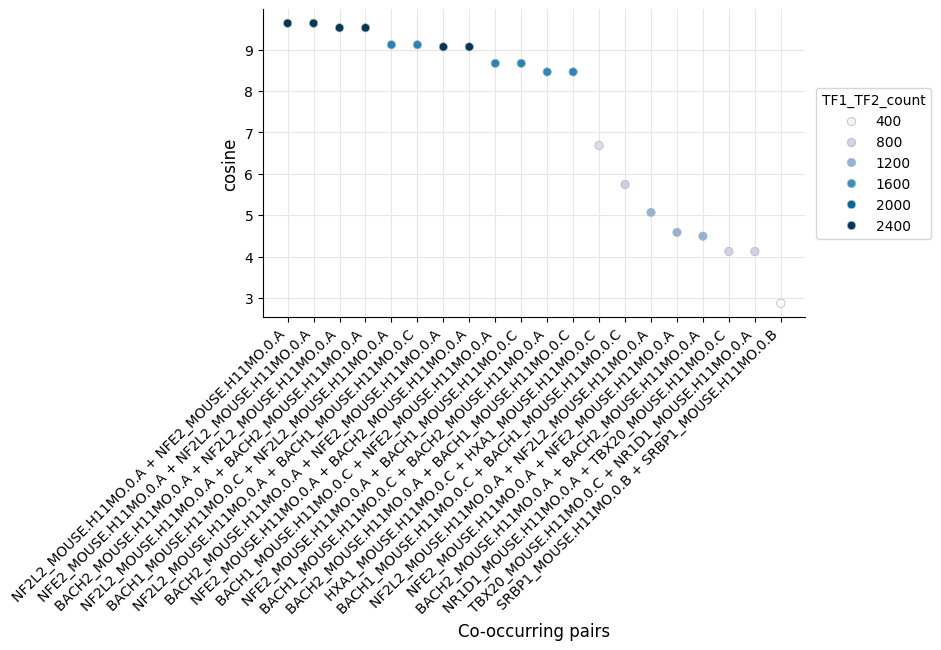

In [8]:
# do it for WT vs SPI2 opened iBMDM peaks
# set up a CombObj
opened = CombObj()

# search for motifs
dir_path = "/scratch/prj/id_hill_sims_wellcda/SteE_revisions/"
opened.TFBS_from_motifs(regions = os.path.join(dir_path, "TF-COMBs/ATACSeq.OCRs.DESeq2.ssaV_vs_WT.SPI2_opened_regions.bed"),
                   motifs = os.path.join(dir_path, "TF-COMBs/HOCOMOCOv11_core_MOUSE_mono_meme_format.meme"),
                   genome = os.path.join(dir_path, "genome.fa"),
                   #motif_pvalue = 0.01, # default is 0.00001
                   threads = 4)

# overwrite counts with larger window
opened.count_within(max_dist=500,
                    #binarize = True, # if True, then each cooccurence is only counted once per window
                    threads=10) 

opened.market_basket(threads=10)


opened.rules
_ = opened.plot_heatmap()
_ = opened.plot_bubble()


In [9]:
# look at all TFBS sites containing STAT3
# this way returns a list of TFBS object
stat3_tfbs1 = [x for x in opened.TFBS if "STAT3" in x.name]
stat3_tfbs1[:5]

len(stat3_tfbs1)
## 47 stat3 sites

# get all STAT3 motif variants
stat3_variants1 = sorted(set(x.name for x in opened.TFBS if "STAT3" in x.name))
print(stat3_variants1)

# filter the significant co-occurrence pairs to those with STAT3 co-occurrence
sorted(set(x.name for x in opened.TFBS if "STAT3" in x.name))

stat3_pairs1 = opened.select_TF_rules(["STAT3_MOUSE.H11MO.0.A"])

stat3_pairs1.rules.head()

[chr1	36569948	36569960	STAT3_MOUSE.H11MO.0.A	9.3781	+,
 chr1	36571689	36571701	STAT3_MOUSE.H11MO.0.A	9.33884	-,
 chr1	36572133	36572145	STAT3_MOUSE.H11MO.0.A	9.37977	+,
 chr1	59316695	59316707	STAT3_MOUSE.H11MO.0.A	9.3636	+,
 chr1	62724672	62724684	STAT3_MOUSE.H11MO.0.A	9.10253	+]

200

['STAT3_MOUSE.H11MO.0.A']


['STAT3_MOUSE.H11MO.0.A']

INFO: Selected 1 rules
INFO: Creating subset of object


,TF1,TF2,TF1_TF2_count,TF1_count,TF2_count,cosine,zscore
STAT3_MOUSE.H11MO.0.A-STAT3_MOUSE.H11MO.0.A,STAT3_MOUSE.H11MO.0.A,STAT3_MOUSE.H11MO.0.A,209,200,200,1.045,70.044287


INFO: Calculating foldchange for contrast: opened / background
INFO: The calculated log2fc's are found in the rules table (<DiffCombObj>.rules)
Index(['TF1', 'TF2', 'opened_cosine', 'background_cosine',
       'opened/background_cosine_log2fc'],
      dtype='object')
All comparisons:


,TF1,TF2,opened_cosine,background_cosine,opened/background_cosine_log2fc
INSM1_MOUSE.H11MO.0.C-ZEB1_MOUSE.H11MO.0.B,INSM1_MOUSE.H11MO.0.C,ZEB1_MOUSE.H11MO.0.B,1.272882,0.088297,3.706093
ZEB1_MOUSE.H11MO.0.B-INSM1_MOUSE.H11MO.0.C,ZEB1_MOUSE.H11MO.0.B,INSM1_MOUSE.H11MO.0.C,1.272882,0.088297,3.706093
SRBP1_MOUSE.H11MO.0.B-SRBP1_MOUSE.H11MO.0.B,SRBP1_MOUSE.H11MO.0.B,SRBP1_MOUSE.H11MO.0.B,2.501497,0.217027,3.467611
OVOL1_MOUSE.H11MO.0.C-BRAC_MOUSE.H11MO.0.B,OVOL1_MOUSE.H11MO.0.C,BRAC_MOUSE.H11MO.0.B,1.058130,0.089813,3.419721
BRAC_MOUSE.H11MO.0.B-OVOL1_MOUSE.H11MO.0.C,BRAC_MOUSE.H11MO.0.B,OVOL1_MOUSE.H11MO.0.C,1.058130,0.089813,3.419721
...,...,...,...,...,...
HNF6_MOUSE.H11MO.0.A-HXB7_MOUSE.H11MO.0.C,HNF6_MOUSE.H11MO.0.A,HXB7_MOUSE.H11MO.0.C,0.026425,5.902386,-7.342660
DDIT3_MOUSE.H11MO.0.C-CEBPG_MOUSE.H11MO.0.B,DDIT3_MOUSE.H11MO.0.C,CEBPG_MOUSE.H11MO.0.B,0.021506,7.209688,-7.840181
CEBPG_MOUSE.H11MO.0.B-DDIT3_MOUSE.H11MO.0.C,CEBPG_MOUSE.H11MO.0.B,DDIT3_MOUSE.H11MO.0.C,0.021506,7.209688,-7.840181
DDIT3_MOUSE.H11MO.0.C-ATF4_MOUSE.H11MO.0.A,DDIT3_MOUSE.H11MO.0.C,ATF4_MOUSE.H11MO.0.A,0.020952,7.289634,-7.881637


Enriched in opened regions:


,TF1,TF2,opened_cosine,background_cosine,opened/background_cosine_log2fc
ZEB1_MOUSE.H11MO.0.B-INSM1_MOUSE.H11MO.0.C,ZEB1_MOUSE.H11MO.0.B,INSM1_MOUSE.H11MO.0.C,1.272882,0.088297,3.706093
INSM1_MOUSE.H11MO.0.C-ZEB1_MOUSE.H11MO.0.B,INSM1_MOUSE.H11MO.0.C,ZEB1_MOUSE.H11MO.0.B,1.272882,0.088297,3.706093
SRBP1_MOUSE.H11MO.0.B-SRBP1_MOUSE.H11MO.0.B,SRBP1_MOUSE.H11MO.0.B,SRBP1_MOUSE.H11MO.0.B,2.501497,0.217027,3.467611
OVOL1_MOUSE.H11MO.0.C-BRAC_MOUSE.H11MO.0.B,OVOL1_MOUSE.H11MO.0.C,BRAC_MOUSE.H11MO.0.B,1.058130,0.089813,3.419721
BRAC_MOUSE.H11MO.0.B-OVOL1_MOUSE.H11MO.0.C,BRAC_MOUSE.H11MO.0.B,OVOL1_MOUSE.H11MO.0.C,1.058130,0.089813,3.419721
E2F5_MOUSE.H11MO.0.B-LHX6_MOUSE.H11MO.0.C,E2F5_MOUSE.H11MO.0.B,LHX6_MOUSE.H11MO.0.C,0.160953,0.006162,3.402942
LHX6_MOUSE.H11MO.0.C-E2F5_MOUSE.H11MO.0.B,LHX6_MOUSE.H11MO.0.C,E2F5_MOUSE.H11MO.0.B,0.160953,0.006162,3.402942
SRBP2_MOUSE.H11MO.0.B-SRBP1_MOUSE.H11MO.0.B,SRBP2_MOUSE.H11MO.0.B,SRBP1_MOUSE.H11MO.0.B,1.391726,0.133067,3.292436
SRBP1_MOUSE.H11MO.0.B-SRBP2_MOUSE.H11MO.0.B,SRBP1_MOUSE.H11MO.0.B,SRBP2_MOUSE.H11MO.0.B,1.391726,0.133067,3.292436
ZEB1_MOUSE.H11MO.0.B-ZEB1_MOUSE.H11MO.0.B,ZEB1_MOUSE.H11MO.0.B,ZEB1_MOUSE.H11MO.0.B,1.835002,0.181615,3.267337


STAT3 is the 13th most enriched TF pair out of all TF pairs


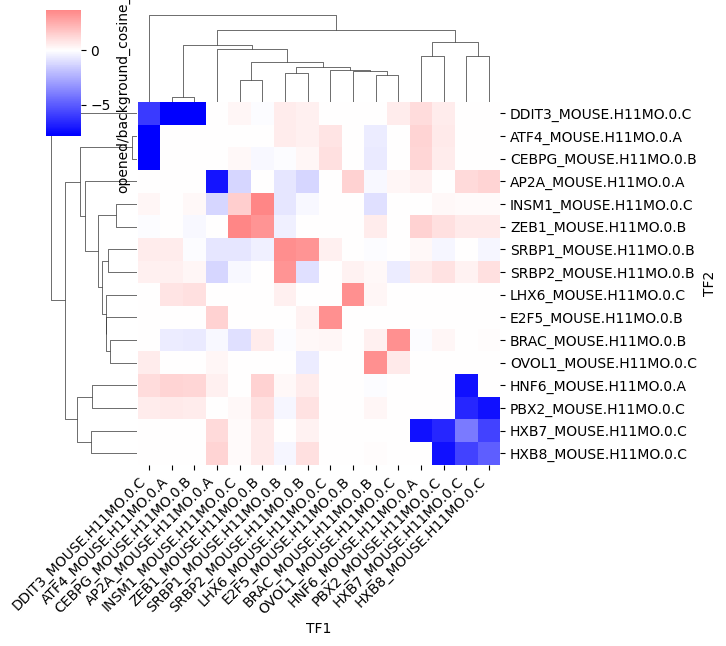

In [10]:
# do differential analysis between background and differentially expressed peaks

# combine the 2 objects, positive log2fc will show TF pairs enriched in the opened regions (first object)
opened.set_prefix("opened")
background.set_prefix("background")

diff = DiffCombObj([opened, background],
                   join = 'inner' # only TFs present on both objects are kept
                       )

# normalise
diff.normalize()

# calculate fold changes
diff.calculate_foldchanges() # use default pseudo = 0.01, defaults to cosine

print(diff.rules.columns)

# print table
print("All comparisons:")
pd.set_option('display.max_columns', None)  # show all columns
pd.set_option('display.width', None)        # auto-detect width
pd.set_option('display.max_colwidth', None) # don't truncate column content
diff.rules.sort_values('opened/background_cosine_log2fc', ascending=False)

print("Enriched in opened regions:")
diff.rules[diff.rules['opened/background_cosine_log2fc'] > 0
    ].sort_values('opened/background_cosine_log2fc', ascending = False
                 ).head(15)


print("STAT3 is the 13th most enriched TF pair out of all TF pairs")

# plot
diff.plot_heatmap()


INFO: Selected 1 rules
INFO: Creating subset of object
Index(['TF1', 'TF2', 'opened_cosine', 'background_cosine',
       'opened/background_cosine_log2fc'],
      dtype='object')
Enriched in opened regions:


,TF1,TF2,opened_cosine,background_cosine,opened/background_cosine_log2fc
STAT3_MOUSE.H11MO.0.A-STAT3_MOUSE.H11MO.0.A,STAT3_MOUSE.H11MO.0.A,STAT3_MOUSE.H11MO.0.A,1.335599,0.140501,3.160406


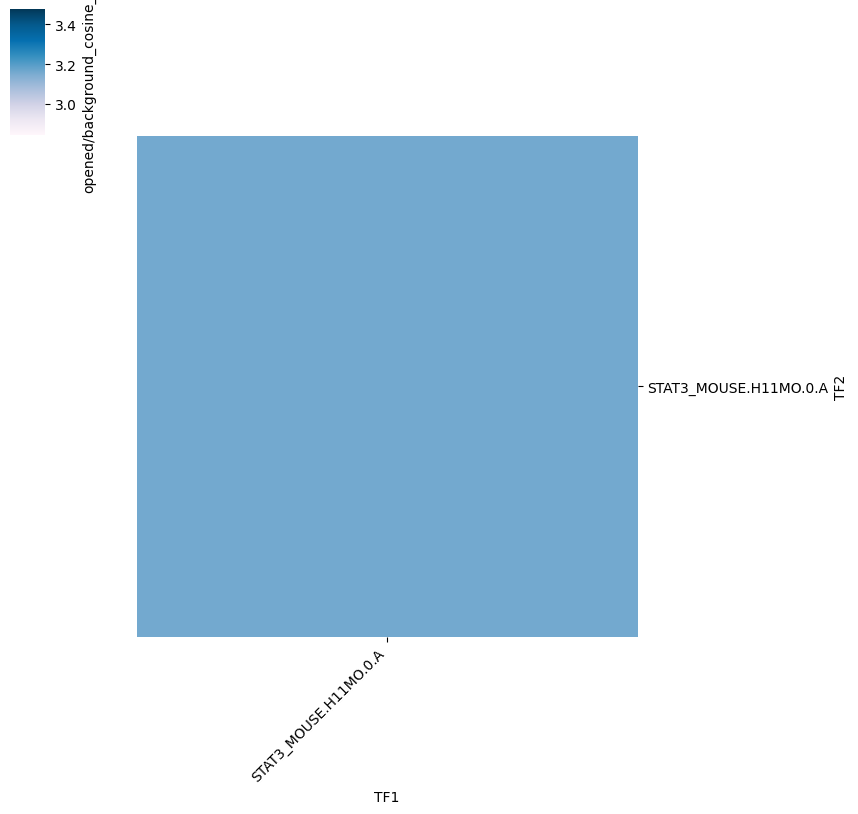

In [11]:
# filter for stat3 pairs enriched in opened regions
diff_stat3 = diff.select_TF_rules(["STAT3_MOUSE.H11MO.0.A"])
print(diff_stat3.rules.columns)

# inspect positive log2fc (enriched in opened vs all)
# print table
print("Enriched in opened regions:")
pd.set_option('display.max_columns', None)  # show all columns
pd.set_option('display.width', None)        # auto-detect width
pd.set_option('display.max_colwidth', None) # don't truncate column content
diff_stat3.rules.sort_values('opened/background_cosine_log2fc', ascending=False)

# plot
diff_stat3.plot_heatmap()

In [12]:
# realised that if filter in a different way, get non-sf tf pairs as well
# select rules only keeps signficant ones - check this is why others aren't showing
diff_stat3_all = diff.rules[
    diff.rules.index.str.contains('STAT3')
].sort_values('opened/background_cosine_log2fc', ascending=False)

print(f"Total STAT3 rows: {len(diff_stat3_all)}")

# Remove duplicates (keep only one direction per pair)
diff_stat3_unique = diff_stat3_all[diff_stat3_all['TF1'] <= diff_stat3_all['TF2']]
print(f"Unique STAT3 pairs: {len(diff_stat3_unique)}")

# Look at top pairs
print("\nTop 10 enriched STAT3 pairs:")
diff_stat3_unique.head(10)

# Check how many are enriched vs depleted
enriched = diff_stat3_unique[diff_stat3_unique['opened/background_cosine_log2fc'] > 0]
depleted = diff_stat3_unique[diff_stat3_unique['opened/background_cosine_log2fc'] < 0]
print(f"\nEnriched in opened: {len(enriched)}")
print(f"Depleted in opened: {len(depleted)}")

# save csv
#enriched.to_csv(os.path.join(dir_path, "TF-COMBs/STAT3_TF_pairs_enrichedInDiffAccessOCRs_500bpwindow.csv"))


Total STAT3 rows: 677
Unique STAT3 pairs: 339

Top 10 enriched STAT3 pairs:


,TF1,TF2,opened_cosine,background_cosine,opened/background_cosine_log2fc
STAT3_MOUSE.H11MO.0.A-STAT3_MOUSE.H11MO.0.A,STAT3_MOUSE.H11MO.0.A,STAT3_MOUSE.H11MO.0.A,1.335599,0.140501,3.160406
OVOL2_MOUSE.H11MO.0.C-STAT3_MOUSE.H11MO.0.A,OVOL2_MOUSE.H11MO.0.C,STAT3_MOUSE.H11MO.0.A,0.115671,0.027294,1.752654
E2F2_MOUSE.H11MO.0.B-STAT3_MOUSE.H11MO.0.A,E2F2_MOUSE.H11MO.0.B,STAT3_MOUSE.H11MO.0.A,0.053152,0.015877,1.287154
STAT3_MOUSE.H11MO.0.A-ZKSC1_MOUSE.H11MO.0.A,STAT3_MOUSE.H11MO.0.A,ZKSC1_MOUSE.H11MO.0.A,0.090729,0.032199,1.255191
P73_MOUSE.H11MO.0.B-STAT3_MOUSE.H11MO.0.A,P73_MOUSE.H11MO.0.B,STAT3_MOUSE.H11MO.0.A,0.074517,0.027396,1.176372
OVOL1_MOUSE.H11MO.0.C-STAT3_MOUSE.H11MO.0.A,OVOL1_MOUSE.H11MO.0.C,STAT3_MOUSE.H11MO.0.A,0.043237,0.013783,1.162527
HXA13_MOUSE.H11MO.0.C-STAT3_MOUSE.H11MO.0.A,HXA13_MOUSE.H11MO.0.C,STAT3_MOUSE.H11MO.0.A,0.070287,0.027616,1.093829
P63_MOUSE.H11MO.0.B-STAT3_MOUSE.H11MO.0.A,P63_MOUSE.H11MO.0.B,STAT3_MOUSE.H11MO.0.A,0.087988,0.036099,1.087854
STAT3_MOUSE.H11MO.0.A-XBP1_MOUSE.H11MO.0.C,STAT3_MOUSE.H11MO.0.A,XBP1_MOUSE.H11MO.0.C,0.028557,0.008522,1.057716
NKX61_MOUSE.H11MO.0.A-STAT3_MOUSE.H11MO.0.A,NKX61_MOUSE.H11MO.0.A,STAT3_MOUSE.H11MO.0.A,0.091270,0.038854,1.051652



Enriched in opened: 228
Depleted in opened: 111


In [13]:
# look at structure of the objects
print("Opened object rules shape:", opened.rules.shape)
print("\nColumns in opened.rules:")
print(opened.rules.columns)

print("Diff object rules shape:", diff.rules.shape)
print("\nColumns in diff.rules:")
print(diff.rules.columns)

Opened object rules shape: (105225, 7)

Columns in opened.rules:
Index(['TF1', 'TF2', 'TF1_TF2_count', 'TF1_count', 'TF2_count', 'cosine',
       'zscore'],
      dtype='object')
Diff object rules shape: (105225, 5)

Columns in diff.rules:
Index(['TF1', 'TF2', 'opened_cosine', 'background_cosine',
       'opened/background_cosine_log2fc'],
      dtype='object')


In [17]:
# generate table for enriched stat3 pairs that has the association rule metrics in it

# get metrics from both objects (excluding cosine since it's already in diff.rules)
opened_metrics = opened.rules[['TF1_TF2_count', 'TF1_count', 'TF2_count', 'zscore']]
opened_metrics.columns = ['opened_cooccur_count', 'opened_TF1_count', 'opened_TF2_count', 'opened_zscore']

background_metrics = background.rules[['TF1_TF2_count', 'TF1_count', 'TF2_count', 'zscore']]
background_metrics.columns = ['background_cooccur_count', 'background_TF1_count', 'background_TF2_count', 'background_zscore']

# merge everything
combined = diff.rules.copy()
combined = combined.join(opened_metrics, how='left')
combined = combined.join(background_metrics, how='left')

# calculate key significance metrics
n_opened_regions = 1385
n_background_regions = 27041

combined['opened_pct_regions'] = (combined['opened_cooccur_count'] / n_opened_regions) * 100
combined['background_pct_regions'] = (combined['background_cooccur_count'] / n_background_regions) * 100

# enrichment ratio (raw fold change, not log2)
combined['enrichment_ratio'] = combined['opened_cosine'] / combined['background_cosine']

# difference in z-scores (higher = more statistically different)
combined['zscore_diff'] = combined['opened_zscore'] - combined['background_zscore']

# absolute counts for context
combined['count_difference'] = combined['opened_cooccur_count'] - combined['background_cooccur_count']

# final table with most relevant columns
significance_table = combined[[
    'TF1', 'TF2',
    # opened metrics
    'opened_cooccur_count', 'opened_pct_regions', 'opened_cosine', 'opened_zscore',
    # background metrics  
    'background_cooccur_count', 'background_pct_regions', 'background_cosine', 'background_zscore',
    # combined comparison metrics
    'opened/background_cosine_log2fc',  # magnitude of enrichment
    'enrichment_ratio',                  # fold change (non-log)
    'zscore_diff',                       # statistical difference
    'count_difference'                   # absolute difference in co-occurrences
]]

# filter for STAT3 enriched pairs and sort
stat3_enriched = significance_table[
    (significance_table.index.str.contains('STAT3')) &
    (significance_table['opened/background_cosine_log2fc'] > 0)
].sort_values('opened/background_cosine_log2fc', ascending=False)

# remove duplicates
stat3_enriched_unique = stat3_enriched[stat3_enriched['TF1'] <= stat3_enriched['TF2']]

print(f"STAT3 enriched pairs: {len(stat3_enriched_unique)}")
stat3_enriched_unique.head(20)

# save
#stat3_enriched_unique.to_csv(os.path.join(dir_path, "TF-COMBs/STAT3_TF_pairs_enrichedInDiffAccessOCRs_500bpwindow_allmetrics.csv"))


STAT3 enriched pairs: 228


,TF1,TF2,opened_cooccur_count,opened_pct_regions,opened_cosine,opened_zscore,background_cooccur_count,background_pct_regions,background_cosine,background_zscore,opened/background_cosine_log2fc,enrichment_ratio,zscore_diff,count_difference
STAT3_MOUSE.H11MO.0.A-STAT3_MOUSE.H11MO.0.A,STAT3_MOUSE.H11MO.0.A,STAT3_MOUSE.H11MO.0.A,209,15.090253,1.335599,70.044287,259,0.957805,0.140501,28.039597,3.160406,9.505993,42.004690,-50
OVOL2_MOUSE.H11MO.0.C-STAT3_MOUSE.H11MO.0.A,OVOL2_MOUSE.H11MO.0.C,STAT3_MOUSE.H11MO.0.A,4,0.288809,0.115671,3.880570,16,0.059169,0.027294,1.576905,1.752654,4.238036,2.303665,-12
E2F2_MOUSE.H11MO.0.B-STAT3_MOUSE.H11MO.0.A,E2F2_MOUSE.H11MO.0.B,STAT3_MOUSE.H11MO.0.A,2,0.144404,0.053152,2.577193,13,0.048075,0.015877,-1.202571,1.287154,3.347717,3.779764,-11
STAT3_MOUSE.H11MO.0.A-ZKSC1_MOUSE.H11MO.0.A,STAT3_MOUSE.H11MO.0.A,ZKSC1_MOUSE.H11MO.0.A,13,0.938628,0.090729,1.073908,46,0.170112,0.032199,-2.175972,1.255191,2.817742,3.249879,-33
P73_MOUSE.H11MO.0.B-STAT3_MOUSE.H11MO.0.A,P73_MOUSE.H11MO.0.B,STAT3_MOUSE.H11MO.0.A,9,0.649819,0.074517,1.017094,40,0.147924,0.027396,-2.627329,1.176372,2.720034,3.644423,-31
OVOL1_MOUSE.H11MO.0.C-STAT3_MOUSE.H11MO.0.A,OVOL1_MOUSE.H11MO.0.C,STAT3_MOUSE.H11MO.0.A,4,0.288809,0.043237,0.214535,12,0.044377,0.013783,-1.397159,1.162527,3.137076,1.611694,-8
HXA13_MOUSE.H11MO.0.C-STAT3_MOUSE.H11MO.0.A,HXA13_MOUSE.H11MO.0.C,STAT3_MOUSE.H11MO.0.A,7,0.505415,0.070287,1.423938,30,0.110943,0.027616,-0.551323,1.093829,2.545177,1.975261,-23
P63_MOUSE.H11MO.0.B-STAT3_MOUSE.H11MO.0.A,P63_MOUSE.H11MO.0.B,STAT3_MOUSE.H11MO.0.A,9,0.649819,0.087988,2.518959,49,0.181206,0.036099,-1.235131,1.087854,2.437376,3.754090,-40
STAT3_MOUSE.H11MO.0.A-XBP1_MOUSE.H11MO.0.C,STAT3_MOUSE.H11MO.0.A,XBP1_MOUSE.H11MO.0.C,1,0.072202,0.028557,0.662266,5,0.018490,0.008522,-1.958666,1.057716,3.350785,2.620932,-4
NKX61_MOUSE.H11MO.0.A-STAT3_MOUSE.H11MO.0.A,NKX61_MOUSE.H11MO.0.A,STAT3_MOUSE.H11MO.0.A,13,0.938628,0.091270,1.454030,54,0.199697,0.038854,-0.956945,1.051652,2.349038,2.410976,-41


In [18]:
# get the metrics used by market basket to determine what is an association or not (only the ones that pass the thresholding are kept)
# want:
    # motif pvalue = statistical significance/motif match
    # support = frequency of tf pair. count(A&B)/total number of windows i.e. baskets
    # confidence P(TF2|TF1). count(A&B)/count(A)
    # lift = enrihcment over random. support(A&B)/ [support(A)*support(B)]

# inside the opened or background object there is:
    # rules = filtered association table with TF1, TF2, support, confidence, lift, count
    # pair_counts = square matrix with TF1, TF2, values = number of regions where they co-occur
    # TFBS = list of individual TFBSs

import pandas as pd
import numpy as np

STAT3 = "STAT3_MOUSE.H11MO.0.A"

# core data
tf_names = opened.count_names
pair_counts = opened.pair_counts      # numpy array
tf_counts = opened.TF_counts           # numpy array
N = max(tf_counts)                     # total windows

i = tf_names.index(STAT3)

rows = []
for j, tf2 in enumerate(tf_names):
    c_xy = pair_counts[i, j]
    c_x = tf_counts[i]
    c_y = tf_counts[j]

    support = c_xy / N if N > 0 else 0
    confidence = c_xy / c_x if c_x > 0 else 0
    lift = (c_xy / N) / ((c_x / N) * (c_y / N)) if c_x > 0 and c_y > 0 else 0

    rows.append((STAT3, tf2, c_xy, support, confidence, lift))

stat3_metrics = pd.DataFrame(
    rows,
    columns=["TF1", "TF2", "cooccurrence_count", "support", "confidence", "lift"]
)

# remove STAT3–STAT3
stat3_metrics = stat3_metrics[stat3_metrics["TF2"] != STAT3]

# sort by lift (or confidence)
stat3_metrics.sort_values(
    ["lift", "confidence", "support"],
    ascending=[False, False, False]
).head(20)

# STAT3-STAT3 homotypic interactions were probably excluded by default from this

,TF1,TF2,cooccurrence_count,support,confidence,lift
230,STAT3_MOUSE.H11MO.0.A,OVOL2_MOUSE.H11MO.0.C,4,0.003182,0.020,4.190000
51,STAT3_MOUSE.H11MO.0.A,E2F2_MOUSE.H11MO.0.B,2,0.001591,0.010,2.095000
232,STAT3_MOUSE.H11MO.0.A,P63_MOUSE.H11MO.0.B,9,0.007160,0.045,1.178438
52,STAT3_MOUSE.H11MO.0.A,E2F3_MOUSE.H11MO.0.A,8,0.006364,0.040,1.169302
340,STAT3_MOUSE.H11MO.0.A,XBP1_MOUSE.H11MO.0.C,1,0.000796,0.005,1.047500
318,STAT3_MOUSE.H11MO.0.A,TBX3_MOUSE.H11MO.0.B,3,0.002387,0.015,1.047500
127,STAT3_MOUSE.H11MO.0.A,HXA13_MOUSE.H11MO.0.C,7,0.005569,0.035,1.023140
55,STAT3_MOUSE.H11MO.0.A,E2F6_MOUSE.H11MO.0.A,11,0.008751,0.055,1.016691
322,STAT3_MOUSE.H11MO.0.A,TEAD4_MOUSE.H11MO.0.A,9,0.007160,0.045,0.992368
203,STAT3_MOUSE.H11MO.0.A,NFYB_MOUSE.H11MO.0.A,6,0.004773,0.030,0.992368


Text(8, 15, 'STAT3-STAT3')

Text(8, 15, 'STAT3-ZN143')

Text(0.5, 1.0, 'STAT3 Pairs – Background Regions')

Text(0.5, 0, 'Cosine Similarity')

Text(0, 0.5, 'Z-score')

...

Text(0.5, 1.0, 'STAT3 Pairs – Opened Regions')

Text(0.5, 0, 'Cosine Similarity')

Text(0, 0.5, 'Z-score')

(-0.042964024552697086, 1.095)

(-10.09623928402801, 75.0442869473708)

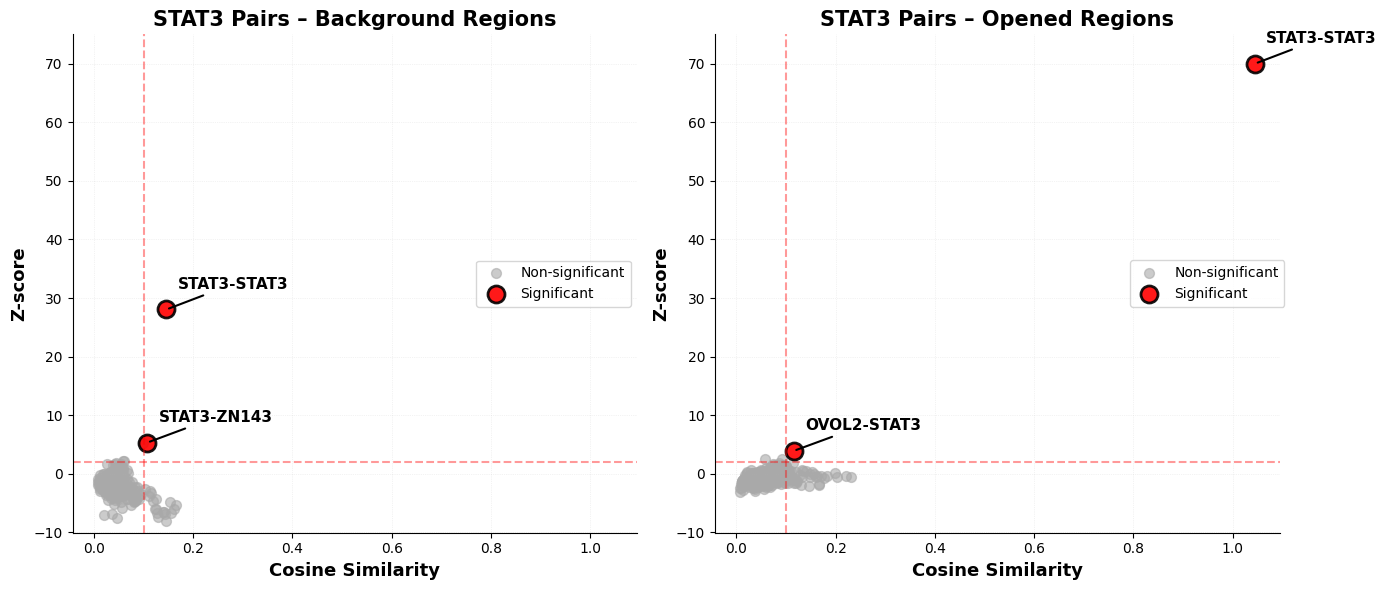


Significant STAT3 pairs in background: 2
                                                               TF1  \
STAT3_MOUSE.H11MO.0.A-STAT3_MOUSE.H11MO.0.A  STAT3_MOUSE.H11MO.0.A   
STAT3_MOUSE.H11MO.0.A-ZN143_MOUSE.H11MO.0.A  STAT3_MOUSE.H11MO.0.A   

                                                               TF2    cosine  \
STAT3_MOUSE.H11MO.0.A-STAT3_MOUSE.H11MO.0.A  STAT3_MOUSE.H11MO.0.A  0.146080   
STAT3_MOUSE.H11MO.0.A-ZN143_MOUSE.H11MO.0.A  ZN143_MOUSE.H11MO.0.A  0.107632   

                                                zscore  
STAT3_MOUSE.H11MO.0.A-STAT3_MOUSE.H11MO.0.A  28.039597  
STAT3_MOUSE.H11MO.0.A-ZN143_MOUSE.H11MO.0.A   5.301022  

Significant STAT3 pairs in opened: 2
                                                               TF1  \
STAT3_MOUSE.H11MO.0.A-STAT3_MOUSE.H11MO.0.A  STAT3_MOUSE.H11MO.0.A   
OVOL2_MOUSE.H11MO.0.C-STAT3_MOUSE.H11MO.0.A  OVOL2_MOUSE.H11MO.0.C   

                                                               TF2   cosine  \
STAT3_M

In [71]:
import matplotlib.pyplot as plt
import numpy as np

# Get all STAT3 pairs
stat3_opened = opened.rules[opened.rules.index.str.contains('STAT3')]
stat3_background = background.rules[background.rules.index.str.contains('STAT3')]

# Remove duplicates
stat3_opened_unique = stat3_opened[stat3_opened['TF1'] <= stat3_opened['TF2']]
stat3_background_unique = stat3_background[stat3_background['TF1'] <= stat3_background['TF2']]

# Identify significant pairs
opened_sig = (stat3_opened_unique['zscore'] > 2) & (stat3_opened_unique['cosine'] > 0.1)
background_sig = (stat3_background_unique['zscore'] > 2) & (stat3_background_unique['cosine'] > 0.1)

# Shared axis limits
all_cosine = np.concatenate([
    stat3_opened_unique['cosine'],
    stat3_background_unique['cosine']
])
all_zscore = np.concatenate([
    stat3_opened_unique['zscore'],
    stat3_background_unique['zscore']
])

xlim = (all_cosine.min() - 0.05, all_cosine.max() + 0.05)
ylim = (all_zscore.min() - 2, all_zscore.max() + 5)

# Create figure (BACKGROUND first)
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# =========================
# Plot 1: BACKGROUND
# =========================
ax_bg = axes[0]

ax_bg.scatter(
    stat3_background_unique.loc[~background_sig, 'cosine'],
    stat3_background_unique.loc[~background_sig, 'zscore'],
    alpha=0.6, s=50, c='darkgray', label='Non-significant', zorder=1
)

ax_bg.scatter(
    stat3_background_unique.loc[background_sig, 'cosine'],
    stat3_background_unique.loc[background_sig, 'zscore'],
    alpha=0.9, s=150, c='red',
    edgecolors='black', linewidths=2,
    label='Significant', zorder=2
)

ax_bg.axhline(2, linestyle='--', color='red', alpha=0.4, linewidth=1.5)
ax_bg.axvline(0.1, linestyle='--', color='red', alpha=0.4, linewidth=1.5)

for _, row in stat3_background_unique[background_sig].iterrows():
    label = f"{row['TF1'].split('_')[0]}-{row['TF2'].split('_')[0]}"
    ax_bg.annotate(
        label,
        (row['cosine'], row['zscore']),
        xytext=(8, 15),
        textcoords='offset points',
        fontsize=11,
        arrowprops=dict(
            arrowstyle='-',
            connectionstyle='arc3,rad=0',
            lw=1.5,
            color='black'
        ),
        fontweight='bold',
        zorder=3
    )

ax_bg.set_title('STAT3 Pairs – Background Regions', fontsize=15, fontweight='bold')
ax_bg.set_xlabel('Cosine Similarity', fontsize=13, fontweight='bold')
ax_bg.set_ylabel('Z-score', fontsize=13, fontweight='bold')
ax_bg.legend(loc='center right', fontsize=10)
ax_bg.grid(alpha=0.3, linestyle=':', linewidth=0.5)
ax_bg.spines['top'].set_visible(False)
ax_bg.spines['right'].set_visible(False)
ax_bg.set_xlim(xlim)
ax_bg.set_ylim(ylim)

# =========================
# Plot 2: OPENED
# =========================
ax_op = axes[1]

ax_op.scatter(
    stat3_opened_unique.loc[~opened_sig, 'cosine'],
    stat3_opened_unique.loc[~opened_sig, 'zscore'],
    alpha=0.6, s=50, c='darkgray', label='Non-significant', zorder=1
)

ax_op.scatter(
    stat3_opened_unique.loc[opened_sig, 'cosine'],
    stat3_opened_unique.loc[opened_sig, 'zscore'],
    alpha=0.9, s=150, c='red',
    edgecolors='black', linewidths=2,
    label='Significant', zorder=2
)

ax_op.axhline(2, linestyle='--', color='red', alpha=0.4, linewidth=1.5)
ax_op.axvline(0.1, linestyle='--', color='red', alpha=0.4, linewidth=1.5)

for _, row in stat3_opened_unique[opened_sig].iterrows():
    label = f"{row['TF1'].split('_')[0]}-{row['TF2'].split('_')[0]}"
    ax_op.annotate(
        label,
        (row['cosine'], row['zscore']),
        xytext=(8, 15),
        textcoords='offset points',
        fontsize=11,
        arrowprops=dict(
            arrowstyle='-',
            connectionstyle='arc3,rad=0',
            lw=1.5,
            color='black'
        ),
        fontweight='bold',
        zorder=3
    )

ax_op.set_title('STAT3 Pairs – Opened Regions', fontsize=15, fontweight='bold')
ax_op.set_xlabel('Cosine Similarity', fontsize=13, fontweight='bold')
ax_op.set_ylabel('Z-score', fontsize=13, fontweight='bold')
ax_op.legend(loc='center right', bbox_to_anchor=(1.02, 0.5), fontsize=10)
ax_op.grid(alpha=0.3, linestyle=':', linewidth=0.5)
ax_op.spines['top'].set_visible(False)
ax_op.spines['right'].set_visible(False)
ax_op.set_xlim(xlim)
ax_op.set_ylim(ylim)

plt.tight_layout()
#plt.savefig(os.path.join(dir_path, "TF-COMBs/STAT3_TF_pairs_scatterplots.pdf"), dpi=300, bbox_inches="tight") 
plt.show()

# Summary
print(f"\nSignificant STAT3 pairs in background: {background_sig.sum()}")
print(stat3_background_unique[background_sig][['TF1', 'TF2', 'cosine', 'zscore']])

print(f"\nSignificant STAT3 pairs in opened: {opened_sig.sum()}")
print(stat3_opened_unique[opened_sig][['TF1', 'TF2', 'cosine', 'zscore']])


Text(25, 3, 'STAT3–STAT3')

Text(0.5, 0, 'log2FC (opened / background)')

Text(0, 0.5, 'Z-score difference')

Text(0.5, 1.0, 'STAT3-containing TF-pair enrichment in opened regions')

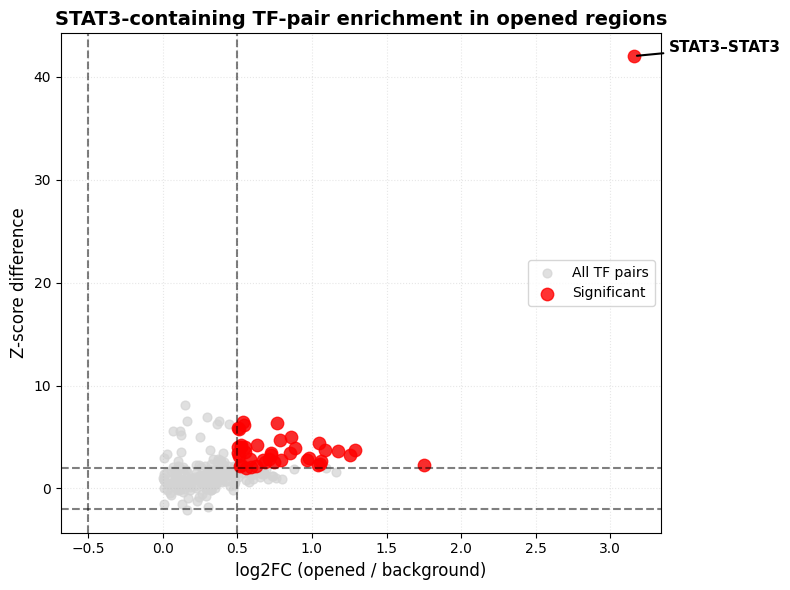

In [70]:
# plot pseudo-volcano plot (as zscore not pvalue)
import matplotlib.pyplot as plt

# Columns for volcano plot
x_col = "opened/background_cosine_log2fc"
y_col = "zscore_diff"

# Define thresholds
x_thresh = 0.5   # example log2FC threshold
y_thresh = 2     # example z-score difference threshold

# Create figure
fig, ax = plt.subplots(figsize=(8, 6))

# Plot all points
ax.scatter(
    df[x_col],
    df[y_col],
    s=40,
    c="lightgray",
    alpha=0.7,
    label="All TF pairs",
    zorder=1
)

# Highlight significant points
sig = (df[x_col].abs() >= x_thresh) & (df[y_col].abs() >= y_thresh)
ax.scatter(
    df.loc[sig, x_col],
    df.loc[sig, y_col],
    s=80,
    c="red",
    alpha=0.8,
    label="Significant",
    zorder=2
)

# Label STAT3–STAT3 with a line (arrow) only
stat3_stat3 = (
    df["TF1"].str.contains("STAT3", case=False, na=False) &
    df["TF2"].str.contains("STAT3", case=False, na=False)
)
for _, row in df.loc[stat3_stat3].iterrows():
    ax.annotate(
        "STAT3–STAT3",
        (row[x_col], row[y_col]),
        xytext=(25, 3),        # offset for text
        textcoords="offset points",
        fontsize=11,
        fontweight="bold",
        color="black",
        arrowprops=dict(arrowstyle="-", lw=1.5, color="black")
    )

# Add threshold lines
ax.axhline(y_thresh, color="black", linestyle="--", alpha=0.5)
ax.axhline(-y_thresh, color="black", linestyle="--", alpha=0.5)
ax.axvline(x_thresh, color="black", linestyle="--", alpha=0.5)
ax.axvline(-x_thresh, color="black", linestyle="--", alpha=0.5)

# Labels and styling
ax.set_xlabel("log2FC (opened / background)", fontsize=12)
ax.set_ylabel("Z-score difference", fontsize=12)
ax.set_title("STAT3-containing TF-pair enrichment in opened regions", fontsize=14, fontweight="bold")
ax.legend()
ax.grid(alpha=0.3, linestyle=":")

plt.tight_layout()
#plt.savefig(os.path.join(dir_path, "TF-COMBs/STAT3_TF_pairs_volcanoplot.pdf"), dpi=300, bbox_inches="tight") 
plt.show()